In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import kagglehub
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Dataset downloaded to:", path)
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Dataset downloaded to: /kaggle/input/gtzan-dataset-music-genre-classification
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [ ]:
import os
import shutil

# 1. Define source and writable paths
# 'path' was defined in the previous cell as '/kaggle/input/gtzan-dataset-music-genre-classification'
base_images_path = os.path.join(path, 'Data', 'images_original')
writable_data_root = '/kaggle/working/gtzan_processed_data'
writable_images_path = os.path.join(writable_data_root, 'Data', 'images_original')

# Clean up existing writable directory if it exists
if os.path.exists(writable_data_root):
    shutil.rmtree(writable_data_root)

# 2. Copy the dataset to the writable directory
# We copy from the parent of 'Data' to maintain structure, or directly from 'Data'
source_to_copy = os.path.join(path, 'Data')
dest_to_copy = os.path.join(writable_data_root, 'Data')
print(f"Copying data from {source_to_copy} to {dest_to_copy}...")
shutil.copytree(source_to_copy, dest_to_copy)

# 3. Navigate to the 'jazz' folder in the writable directory
jazz_path = os.path.join(writable_images_path, 'jazz')

# 4. Identify an image and duplicate it
jazz_images = sorted([f for f in os.listdir(jazz_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
if len(jazz_images) == 99:
    src_file = os.path.join(jazz_path, jazz_images[0])
    dest_file = os.path.join(jazz_path, 'jazz00077_duplicate.png')
    shutil.copy2(src_file, dest_file)
    print(f"Duplicated {jazz_images[0]} to jazz00077_duplicate.png")

# 5. Verify and print results
final_jazz_count = len([f for f in os.listdir(jazz_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
print(f"Updated writable images path: {writable_images_path}")
print(f"Total images in 'jazz' folder: {final_jazz_count}")

Copying data from /kaggle/input/gtzan-dataset-music-genre-classification/Data to /kaggle/working/gtzan_processed_data/Data...
Duplicated jazz00000.png to jazz00077_duplicate.png
Updated writable images path: /kaggle/working/gtzan_processed_data/Data/images_original
Total images in 'jazz' folder: 100


In [ ]:
import os
import shutil

# 1. Define base directory for the split dataset
split_base_dir = '/kaggle/working/gtzan_split'

# 2. Remove existing directory if it exists for a clean start
if os.path.exists(split_base_dir):
    shutil.rmtree(split_base_dir)
    print(f"Removed existing directory: {split_base_dir}")

# 3. Define splits and 4. Identify genres
splits = ['train', 'val', 'test']
# Extract genres from the writable images folder prepared in the previous subtask
genres = sorted([d for d in os.listdir(writable_images_path) if os.path.isdir(os.path.join(writable_images_path, d))])

# 5. Create nested directory structure
for split in splits:
    for genre in genres:
        path = os.path.join(split_base_dir, split, genre)
        os.makedirs(path, exist_ok=True)

# 6. Confirmation and verification
print(f"Created directory structure at: {split_base_dir}")
print(f"Genres identified: {genres}")
print(f"Contents of {os.path.join(split_base_dir, 'train')}:", os.listdir(os.path.join(split_base_dir, 'train')))

Created directory structure at: /kaggle/working/gtzan_split
Genres identified: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Contents of /kaggle/working/gtzan_split/train: ['pop', 'blues', 'reggae', 'country', 'jazz', 'rock', 'classical', 'metal', 'hiphop', 'disco']


In [ ]:
import random
import shutil

# 1. & 2. Set random seed for reproducibility
random.seed(42)

# 3. Define split ratios
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# Valid extensions for filtering
valid_extensions = ('.png', '.jpg', '.jpeg')

# 4. Iterate through each genre
for genre in genres:
    # a. List all image files from the source genre folder
    genre_src_path = os.path.join(writable_images_path, genre)
    images = [f for f in os.listdir(genre_src_path) if f.lower().endswith(valid_extensions)]

    # b. Shuffle the list of image files
    random.shuffle(images)

    # c. Calculate split indices
    num_images = len(images)
    train_end = int(num_images * TRAIN_RATIO)
    val_end = train_end + int(num_images * VAL_RATIO)

    image_splits = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    # d. Copy files to designated split and genre folder
    for split_name, split_files in image_splits.items():
        dest_dir = os.path.join(split_base_dir, split_name, genre)
        for img_name in split_files:
            src_file = os.path.join(genre_src_path, img_name)
            shutil.copy2(src_file, dest_dir)

# 5. Print confirmation
print(f"Successfully distributed images for {len(genres)} genres into '{split_base_dir}' using an 80/10/10 split.")

Successfully distributed images for 10 genres into '/kaggle/working/gtzan_split' using an 80/10/10 split.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# 1. & 2. Define image transformations
# Resizing to 224x224 and converting to Tensor (scales pixels to [0, 1])
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 3. & 4. Create ImageFolder datasets with transformations applied
train_dataset = ImageFolder(root=os.path.join(split_base_dir, 'train'), transform=data_transforms)
val_dataset = ImageFolder(root=os.path.join(split_base_dir, 'val'), transform=data_transforms)
test_dataset = ImageFolder(root=os.path.join(split_base_dir, 'test'), transform=data_transforms)

# 5. Print counts to verify
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Detected classes: {train_dataset.classes}")

Number of training samples: 800
Number of validation samples: 100
Number of test samples: 100
Detected classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
from torch.utils.data import DataLoader

# 1. & 2. Create DataLoader for training dataset (shuffled)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. Create DataLoaders for validation and test datasets (not shuffled)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Verify the number of batches
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 25
Validation batches: 4
Test batches: 4


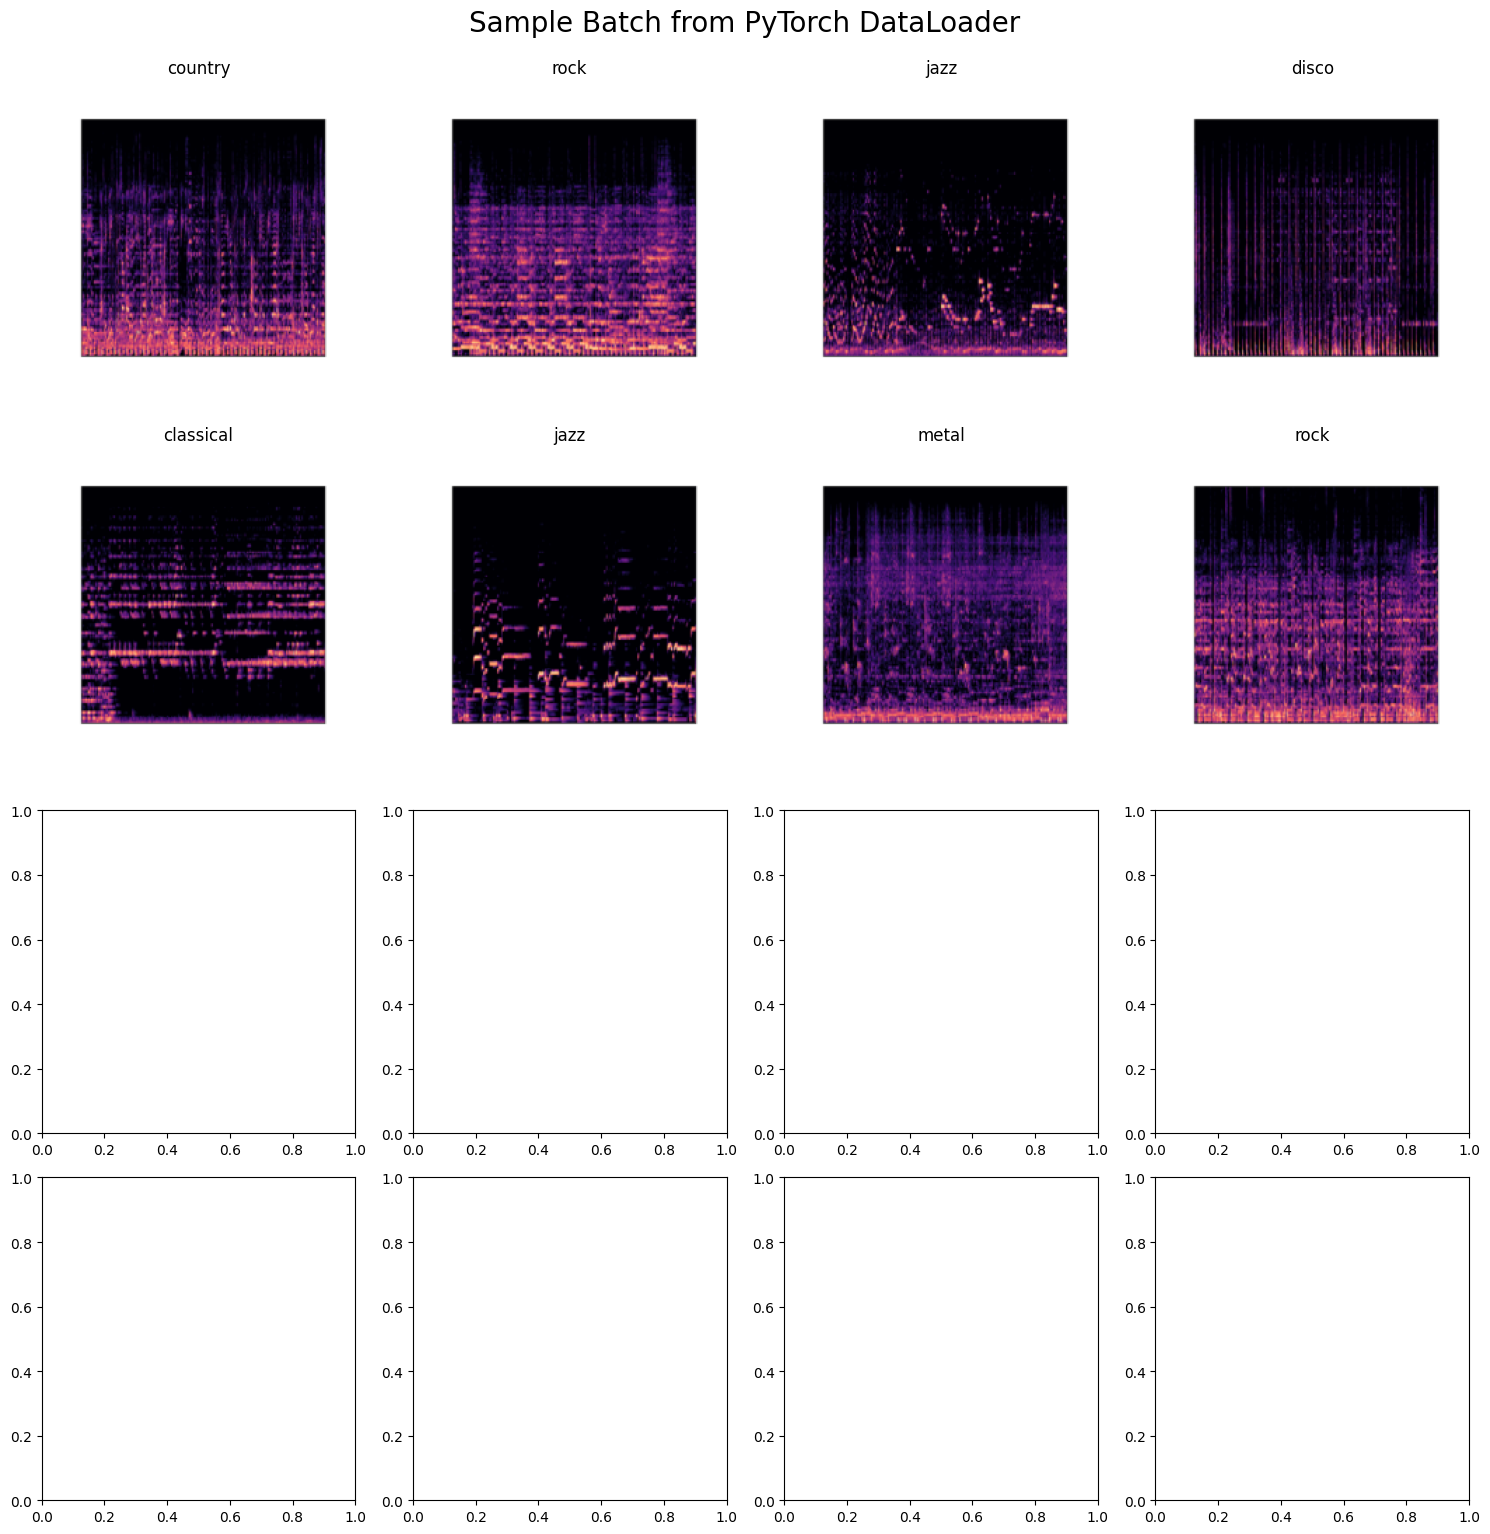

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 2. Obtain a single batch of images and labels
images, labels = next(iter(train_loader))

# 3. Create a figure with a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

# 4. Iterate through the first 16 images and labels
for i in range(8):
    # a. Convert PyTorch tensor to NumPy array
    img = images[i].numpy()

    # b. Transpose dimensions from (C, H, W) to (H, W, C)
    img = np.transpose(img, (1, 2, 0))

    # c. Retrieve the class name
    label_idx = labels[i].item()
    genre_name = train_dataset.classes[label_idx]

    # d. Display image and set title
    axes[i].imshow(img)
    axes[i].set_title(genre_name)

    # e. Disable axis
    axes[i].axis('off')

# 5. Adjust layout and show
plt.tight_layout()
plt.suptitle('Sample Batch from PyTorch DataLoader', fontsize=20, y=1.02)
plt.show()